Running 8 simulations...
  τ=0.0...
  τ=1.4...
  τ=1.8...
  τ=2.0...
  τ=3.0...
  τ=5.6...
  τ=5.8...
  τ=6.6...
All simulations complete!


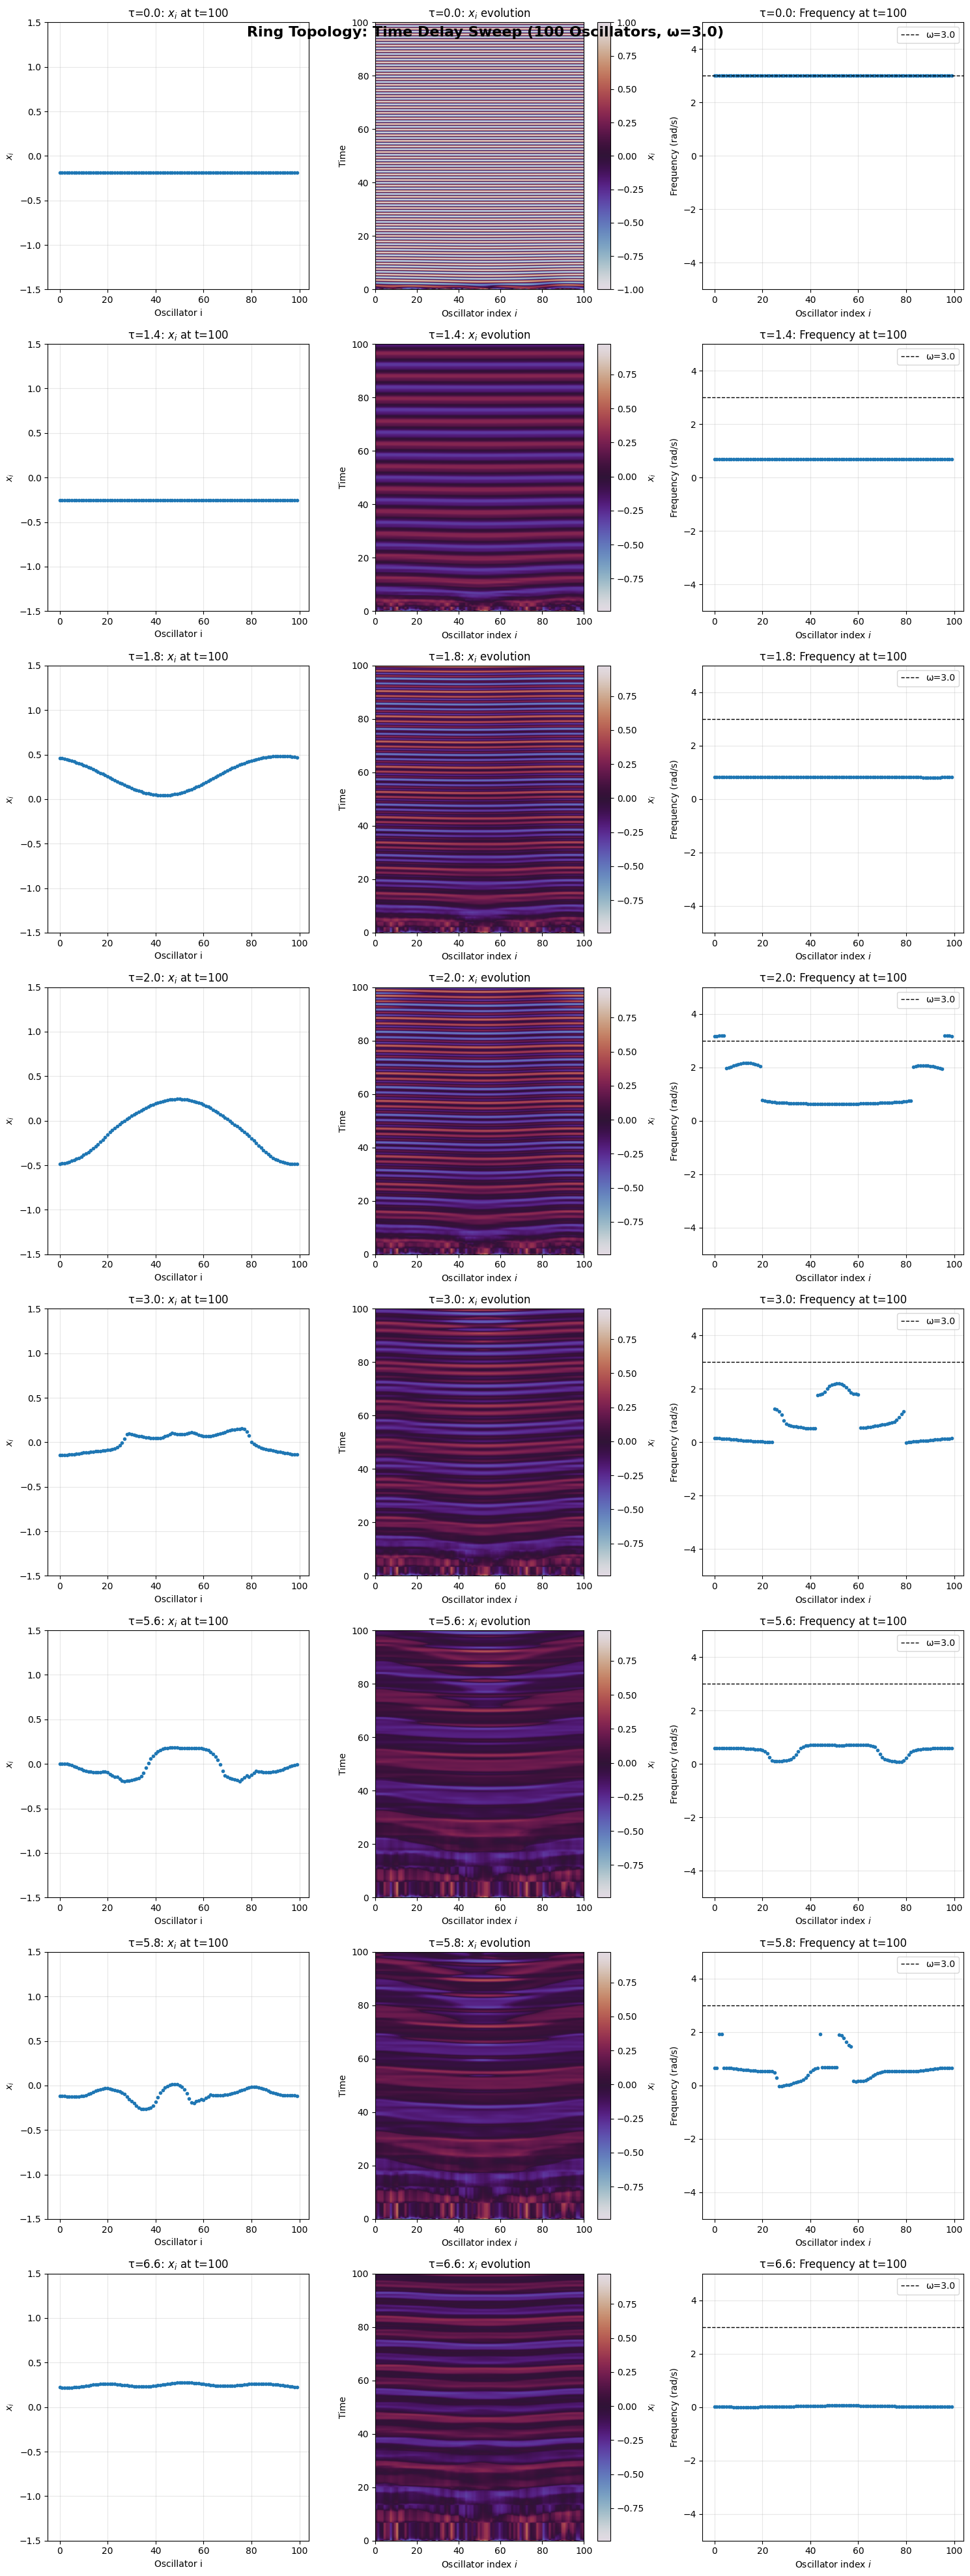

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameters for Ring Topology (Fixed Frequency)
# ==========================================
N = 100         # Number of oscillators
S = 3      # Coupling range
R = 1           # Radius parameter
a = 1           # Damping parameter
sigma = 10   # Coupling strength
w_fixed = 3.0   # Fixed frequency for all oscillators

# Time parameters
t0 = 0
T = 100
h = 0.1
steps = int((T - t0) / h)



# ==========================================
# Tau values to simulate
# ==========================================
tau_values =[0.0] + [1.4]+ [1.8]+ [2]+[3]+ [5.6]+ [5.8]+ [6.6]

# ==========================================
# Helper Functions
# ==========================================

def get_delayed_value(history, time_delaysteps, current_idx, osc_idx):
    """Get delayed value for oscillator osc_idx at current time step"""
    idx = current_idx - time_delaysteps
    if idx < 0:
        return history[0, osc_idx]
    else:
        return history[idx, osc_idx]

def coupling_sum(var_current, var_delayed, i, S, coupling_strength, use_delay):
    """Calculate coupling sum for oscillator i"""
    coupling = 0.0
    for j in range(-S, S + 1):
        if j != 0:
            neighbor_idx = (i + j) % N
            if use_delay:
                coupling += coupling_strength * (var_delayed[neighbor_idx] - var_current[i])
            else:
                coupling += coupling_strength * (var_current[neighbor_idx] - var_current[i])
    return coupling / (2 * S)

# ==========================================
# Derivative Functions
# ==========================================

def derivatives(x, y, x_delayed, use_delay):
    """Compute derivatives for all oscillators - delay only in x"""
    dx = np.zeros(N)
    dy = np.zeros(N)

    for i in range(N):
        r = np.sqrt(x[i]**2 + y[i]**2)

        # Coupling term with delay only in x
        coupling_x = sigma * coupling_sum(x, x_delayed, i, S, 1, use_delay)
        # No delay in y coupling - always use current values
        coupling_y = sigma * coupling_sum(y, y, i, S, 1, use_delay=False)

        # Dynamics with fixed frequency
        dx[i] = -a * x[i] + (a * R / r) * x[i] - w_fixed * y[i] + coupling_x
        dy[i] = -a * y[i] + (a * R / r) * y[i] + w_fixed * x[i] + coupling_y

    return dx, dy

# ==========================================
# Frequency Calculation
# ==========================================

def calculate_frequencies(x_hist, y_hist, h, window=50):
    """Calculate instantaneous frequency from phase evolution"""
    freq_hist = np.zeros((x_hist.shape[0], N))

    for t in range(x_hist.shape[0]):
        for i in range(N):
            # Calculate phase at current time
            if t >= window:
                # Use a window of past values for more stable frequency estimate
                phases = np.arctan2(y_hist[t-window:t+1, i], x_hist[t-window:t+1, i])

                # Unwrap phases to handle 2π discontinuities
                phases_unwrapped = np.unwrap(phases)

                # Estimate frequency as derivative of phase
                freq_hist[t, i] = (phases_unwrapped[-1] - phases_unwrapped[0]) / (window * h)
            else:
                # For early times, use current values or simple estimate
                if t > 0:
                    phase_curr = np.arctan2(y_hist[t, i], x_hist[t, i])
                    phase_prev = np.arctan2(y_hist[t-1, i], x_hist[t-1, i])
                    # Handle wraparound
                    dphi = phase_curr - phase_prev
                    if dphi > np.pi:
                        dphi -= 2*np.pi
                    elif dphi < -np.pi:
                        dphi += 2*np.pi
                    freq_hist[t, i] = dphi / h
                else:
                    freq_hist[t, i] = w_fixed  # Initial estimate

    return freq_hist

# ==========================================
# RK4 Solver with Time Delay (X only)
# ==========================================

def rk4_with_delay(x0, y0, time_delaysteps, use_delay):
    """Simulate ring topology WITH or WITHOUT time delay in x only"""
    # Initialize history
    x_hist = np.zeros((steps + 1, N))
    y_hist = np.zeros((steps + 1, N))

    # Set initial conditions
    x_hist[0] = x0.copy()
    y_hist[0] = y0.copy()

    x = x0.copy()
    y = y0.copy()

    for t in range(steps):
        # Get delayed values for x only
        if use_delay and time_delaysteps > 0:
            x_delayed = np.array([get_delayed_value(x_hist, time_delaysteps, t, i) for i in range(N)])
        else:
            x_delayed = x.copy()

        # RK4 steps
        dx1, dy1 = derivatives(x, y, x_delayed, use_delay)

        dx2, dy2 = derivatives(x + 0.5 * h * dx1,
                              y + 0.5 * h * dy1,
                              x_delayed, use_delay)

        dx3, dy3 = derivatives(x + 0.5 * h * dx2,
                              y + 0.5 * h * dy2,
                              x_delayed, use_delay)

        dx4, dy4 = derivatives(x + h * dx3,
                              y + h * dy3,
                              x_delayed, use_delay)

        # Update
        x += (h / 6) * (dx1 + 2 * dx2 + 2 * dx3 + dx4)
        y += (h / 6) * (dy1 + 2 * dy2 + 2 * dy3 + dy4)

        # Store
        x_hist[t + 1] = x
        y_hist[t + 1] = y

    return x_hist, y_hist

# ==========================================
# Initial Conditions
# ==========================================
np.random.seed(42)  # For reproducibility
x0 = np.random.uniform(-1, 1, N)
y0 = np.random.uniform(-1, 1, N)

# ==========================================
# Run Simulations for All Tau Values
# ==========================================
results = {}

print(f"Running {len(tau_values)} simulations...")
for tau in tau_values:
    time_delaysteps = int(tau / h)
    use_delay = (tau > 0)

    print(f"  τ={tau:.1f}...")
    x_hist, y_hist = rk4_with_delay(x0, y0, time_delaysteps, use_delay)
    freq_hist = calculate_frequencies(x_hist, y_hist, h)

    results[tau] = {
        'x_hist': x_hist,
        'y_hist': y_hist,
        'freq_hist': freq_hist
    }

print("All simulations complete!")
# ==========================================
# Visualization - One row per tau value
# ==========================================
n_rows = len(tau_values)
n_cols = 3  # Changed from 4 to 3
fig = plt.figure(figsize=(15, 5*n_rows)) # Adjusted width slightly

# Create time array for time series plots (unused now, but kept for compatibility)
time_array = np.linspace(t0, T, steps + 1)

for idx, tau in enumerate(tau_values):
    data = results[tau]

    # Column 1: x_i at final time
    ax1 = plt.subplot(n_rows, n_cols, idx*n_cols + 1)
    ax1.plot(np.arange(N), data['x_hist'][-1], 'o', markersize=3)
    ax1.set_title(f"τ={tau:.1f}: $x_i$ at t={T}")
    ax1.set_xlabel("Oscillator i")
    ax1.set_ylabel("$x_i$")
    ax1.set_ylim([-1.5, 1.5])
    ax1.grid(True, alpha=0.3)

    # Column 2: x space-time
    ax2 = plt.subplot(n_rows, n_cols, idx*n_cols + 2)
    im1 = ax2.imshow(data['x_hist'], aspect='auto', cmap='twilight',
                     extent=[0, N, 0, T], origin='lower')
    ax2.set_title(f"τ={tau:.1f}: $x_i$ evolution")
    ax2.set_xlabel("Oscillator index $i$")
    ax2.set_ylabel("Time")
    plt.colorbar(im1, ax=ax2, label="$x_i$")

    # Column 3: Frequency at final time (Previously Column 4)
    ax3 = plt.subplot(n_rows, n_cols, idx*n_cols + 3)
    ax3.plot(np.arange(N), data['freq_hist'][-1], 'o', markersize=3)
    ax3.axhline(y=w_fixed, color='black', linestyle='--', linewidth=1,
                label=f'ω={w_fixed}')
    ax3.set_title(f"τ={tau:.1f}: Frequency at t={T}")
    ax3.set_xlabel("Oscillator index $i$")
    ax3.set_ylabel("Frequency (rad/s)")
    ax3.set_ylim([-5, 5])
    ax3.grid(True, alpha=0.3)
    ax3.legend()

plt.suptitle(f"Ring Topology: Time Delay Sweep ({N} Oscillators, ω={w_fixed})",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()